# Question 8 — Salt and Pepper Noise Filtering
- (a) Apply Gaussian smoothing
- (b) Apply median filtering

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

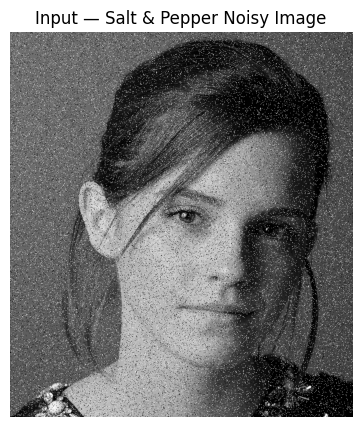

In [2]:
# Load the noisy image (given input)
noisy = cv.imread('images/emma_noisy.png', cv.IMREAD_GRAYSCALE)
assert noisy is not None
show_gray(noisy, 'Input — Salt & Pepper Noisy Image')

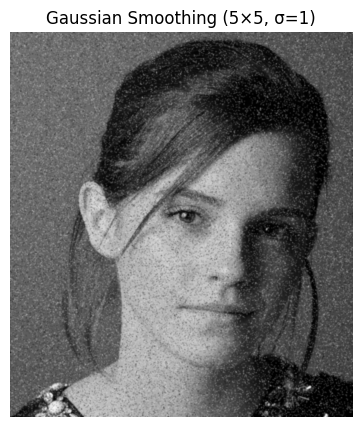

True

In [3]:
# (a) Gaussian smoothing
# Averages neighbouring pixels — blurs noise but also blurs edges.
# Not ideal for salt & pepper: extreme outlier pixels (0 or 255)
# pull the local average away from the true value.
gaussian = cv.GaussianBlur(noisy, (5, 5), 1)
show_gray(gaussian, 'Gaussian Smoothing (5×5, σ=1)')
cv.imwrite('outputs/q8a_gaussian.png', gaussian)

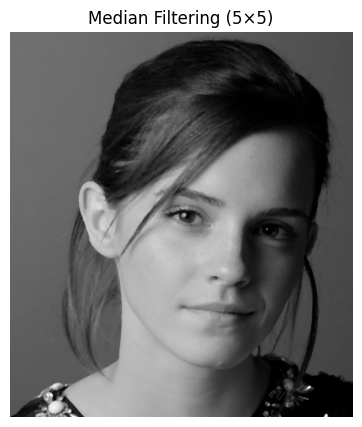

True

In [4]:
# (b) Median filtering
# Replaces each pixel with the median of its neighbourhood.
# Salt/pepper pixels (0 or 255) are extreme outliers — they rarely
# become the median, so they get removed cleanly without blurring edges.
median = cv.medianBlur(noisy, 5)
show_gray(median, 'Median Filtering (5×5)')
cv.imwrite('outputs/q8b_median.png', median)

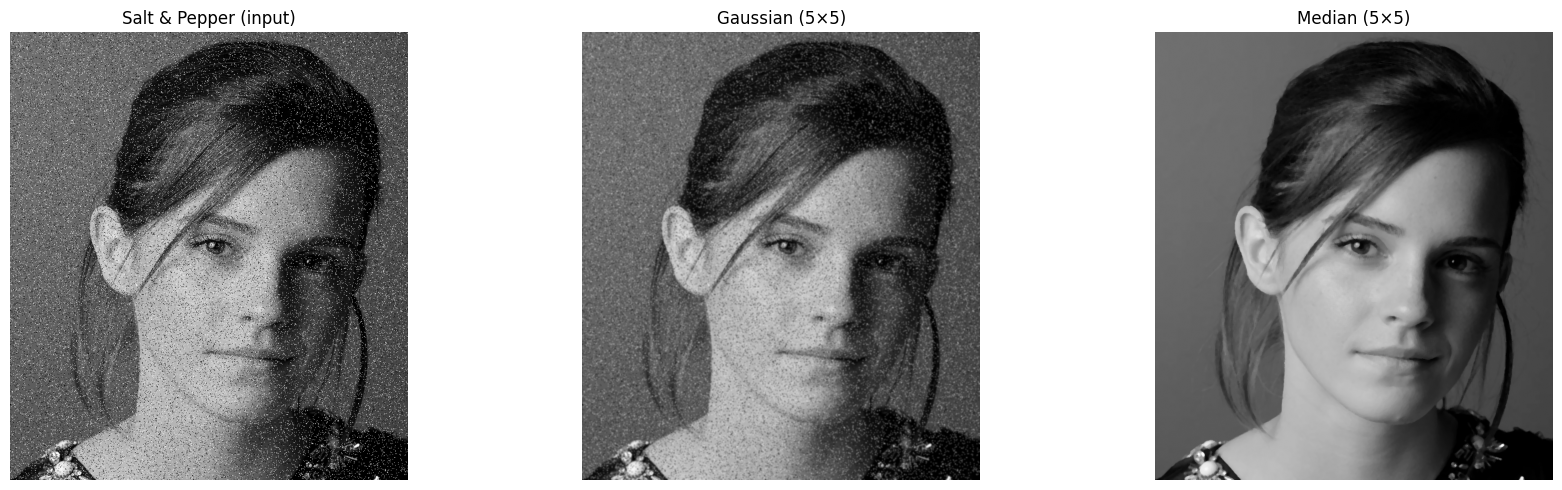

Conclusion:
  Median filter handles salt & pepper noise far better than Gaussian.
  Gaussian spreads and blurs the noise; median removes outliers cleanly
  while preserving edges — making it the preferred filter for this noise type.


In [5]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, img, title in zip(axes,
    [noisy, gaussian, median],
    ['Salt & Pepper (input)', 'Gaussian (5×5)', 'Median (5×5)']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q8_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conclusion:')
print('  Median filter handles salt & pepper noise far better than Gaussian.')
print('  Gaussian spreads and blurs the noise; median removes outliers cleanly')
print('  while preserving edges — making it the preferred filter for this noise type.')

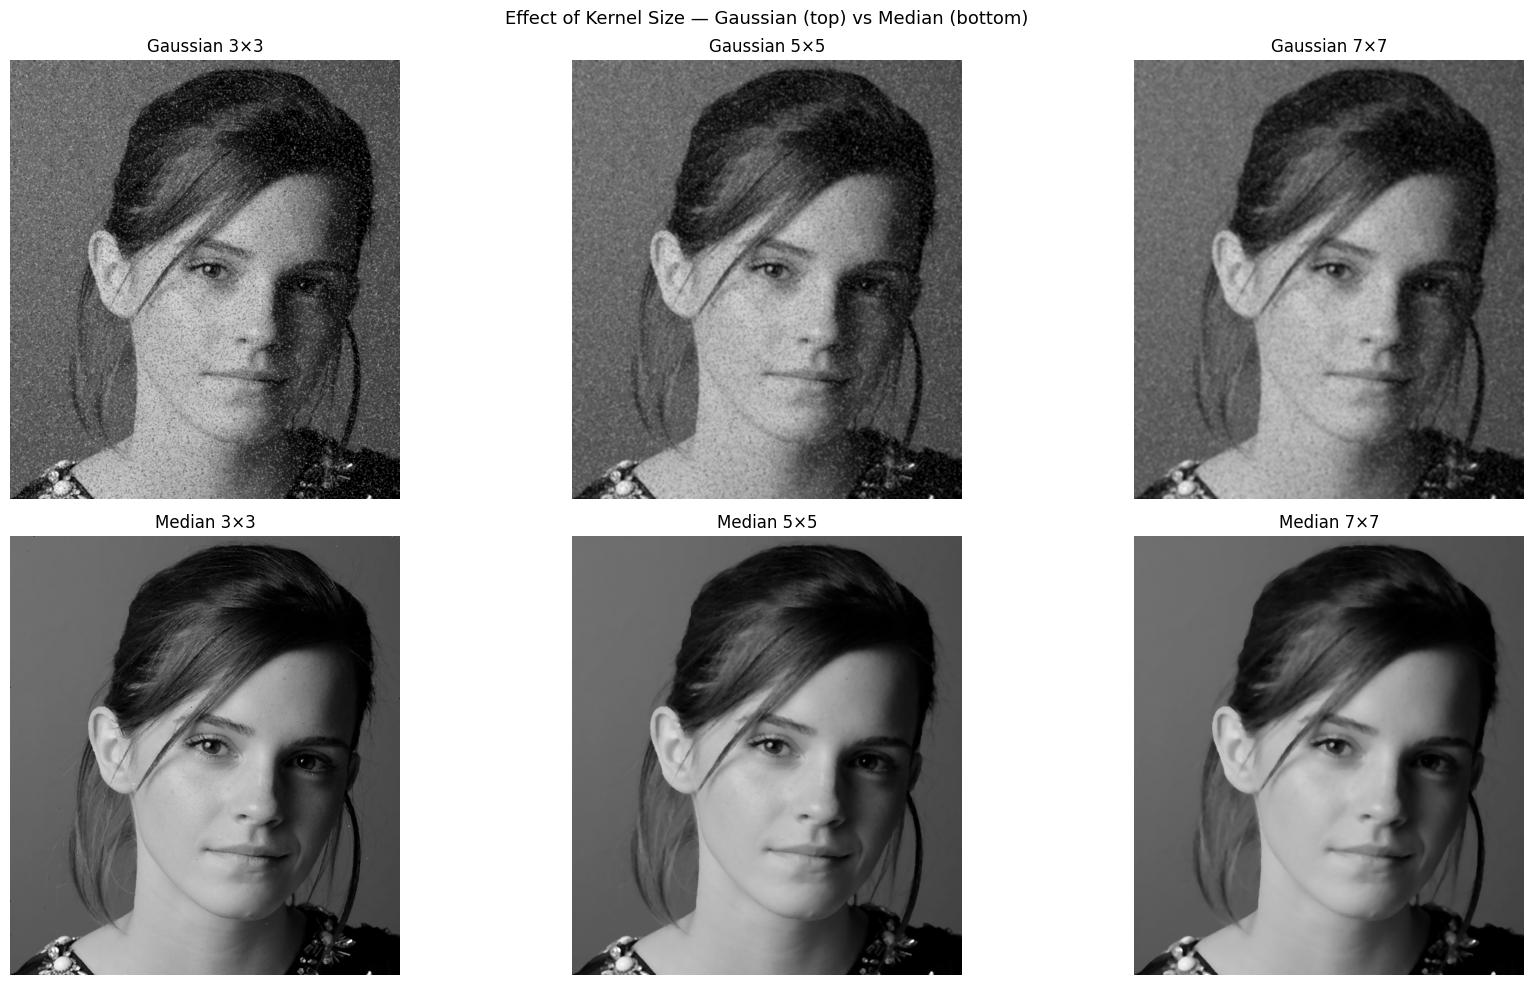

In [6]:
# Effect of kernel size on both filters
sizes = [3, 5, 7]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, k in enumerate(sizes):
    g = cv.GaussianBlur(noisy, (k, k), k / 3)
    m = cv.medianBlur(noisy, k)
    axes[0, i].imshow(g, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'Gaussian {k}×{k}'); axes[0, i].axis('off')
    axes[1, i].imshow(m, cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title(f'Median {k}×{k}');   axes[1, i].axis('off')

plt.suptitle('Effect of Kernel Size — Gaussian (top) vs Median (bottom)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/q8_kernel_sizes.png', dpi=150, bbox_inches='tight')
plt.show()